In [1]:
import xarray as xr
import glob
import xrft
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid
from datatree import open_datatree, DataTree 

In [2]:
ds = xr.open_mfdataset('/home/db194/scratch_db194/OM4_jun_2025/test_my_ANN/19770101.prog__007*.nc')

ERROR 1: PROJ: proj_create_from_database: Open of /ext3/miniforge/share/proj failed


In [3]:
ds

<xarray.Dataset>
Dimensions:          (xq: 1440, yh: 1080, zl: 75, time: 1, xh: 1440, yq: 1080,
                      zi: 76)
Coordinates:
  * xq               (xq) float64 -299.6 -299.3 -299.1 ... 59.66 59.91 60.16
  * yh               (yh) float64 -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * zl               (zl) float64 1.0 3.0 5.0 ... 3.338e+03 3.591e+03 5.111e+03
  * time             (time) object 1977-01-01 12:00:00
  * xh               (xh) float64 -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * yq               (yq) float64 -80.35 -80.27 -80.19 ... 89.78 89.89 90.0
  * zi               (zi) float64 0.0 2.0 4.0 ... 3.461e+03 3.722e+03 6.5e+03
Data variables: (12/33)
    u                (time, zl, yh, xq) float32 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    v                (time, zl, yq, xh) float32 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    h                (time, zl, yh, xh) float64 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    e                (time, zi, yh, xh) float64 dask.array<chunksize=(1, 76, 1080, 1440), meta=np.ndarray>
    Rd1              (time, yh, xh) float64 dask.array<chunksize=(1, 1080, 1440), meta=np.ndarray>
    ssh              (time, yh, xh) float64 dask.array<chunksize=(1, 1080, 1440), meta=np.ndarray>
    ...               ...
    boundary_mask    (time, zl, yh, xh) float64 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    MLD_003          (time, yh, xh) float32 dask.array<chunksize=(1, 1080, 1440), meta=np.ndarray>
    rhopot0          (time, zl, yh, xh) float32 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    thetao           (time, zl, yh, xh) float32 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    so               (time, zl, yh, xh) float32 dask.array<chunksize=(1, 75, 1080, 1440), meta=np.ndarray>
    N2               (time, zi, yh, xh) float32 dask.array<chunksize=(1, 76, 1080, 1440), meta=np.ndarray>
Attributes:
    filename:   19770101.prog__00721240.nc
    title:      OM4_SIS2_cgrid_025
    grid_type:  regular
    grid_tile:  N/A

In [3]:
ds_grid = xr.open_mfdataset('/home/db194/scratch_db194/OM4_jun_2025/test_my_ANN/ocean_geometry.nc')

/ext3/miniforge/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in log10
  return func(*(_execute_task(a, cache) for a in args))


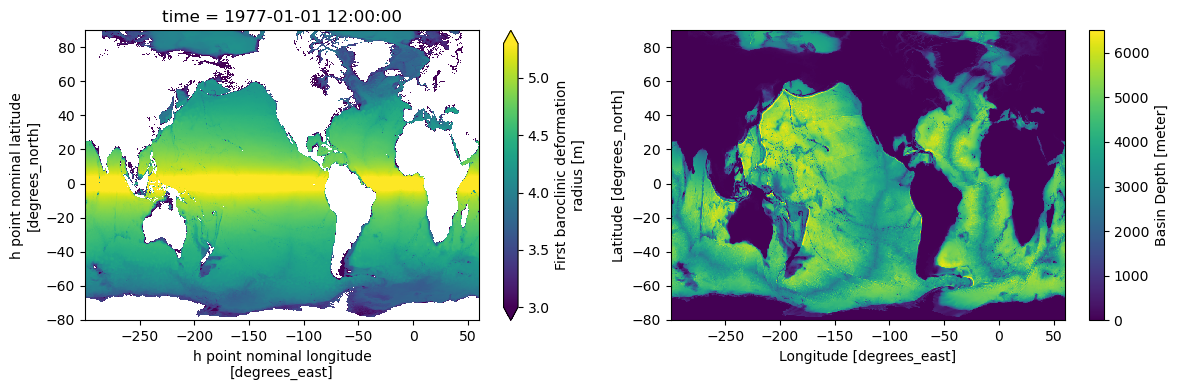

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
np.log10(ds.Rd1).isel(time=-1).plot(vmin=3, vmax=5.3)

plt.subplot(122)
ds_grid.D.plot()

plt.tight_layout()

## Velocity gradients

!! Not saved

## Thickness gradients

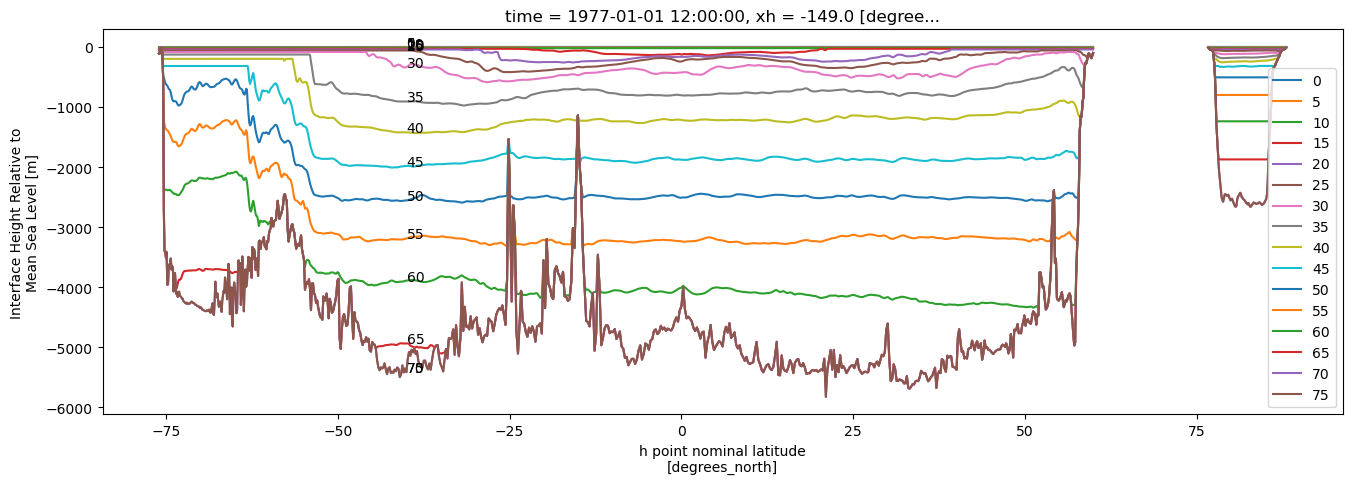

In [48]:
plt.figure(figsize=(16, 5))
xsel = -149

for i in range(0,76, 5):
    ds.e.isel(time=0, zi=i).sel(xh=xsel, method='nearest').plot(label=i)
    plt.text(-40, ds.e.isel(time=0, zi=i).sel(xh=xsel, yh=-40, method='nearest').values, str(i))
plt.legend()

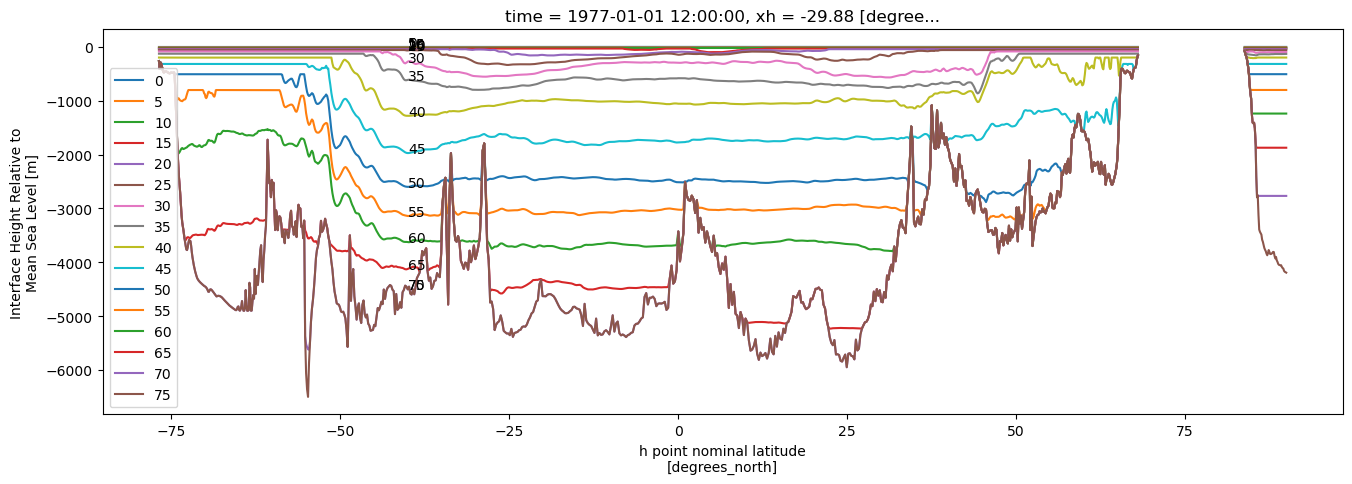

In [47]:
plt.figure(figsize=(16, 5))
xsel = -30
for i in range(0,76, 5):
    ds.e.isel(time=0, zi=i).sel(xh=xsel, method='nearest').plot(label=i)
    plt.text(-40, ds.e.isel(time=0, zi=i).sel(xh=xsel, yh=-40, method='nearest').values, str(i))
plt.legend()

In [4]:
def plot_om4_section_yqi(ds=ds, var='neutral_slope_y', 
                     tsel=0, 
                     yh_sel = slice(-75,60),
                     yq_sel = slice(-75,59.9), 
                     xsel = -149) :
    
    e = ds.e.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
    x = ds.yh.sel(yh=yh_sel).data
    c = ds[var].isel(time=tsel).sel(yq=yq_sel).sel(xh=xsel, method='nearest').data
    plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2, cmap='RdBu_r')
    plt.colorbar()
    plt.grid()


/state/partition1/job-62242391/ipykernel_3904893/724297832.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2, cmap='RdBu_r')


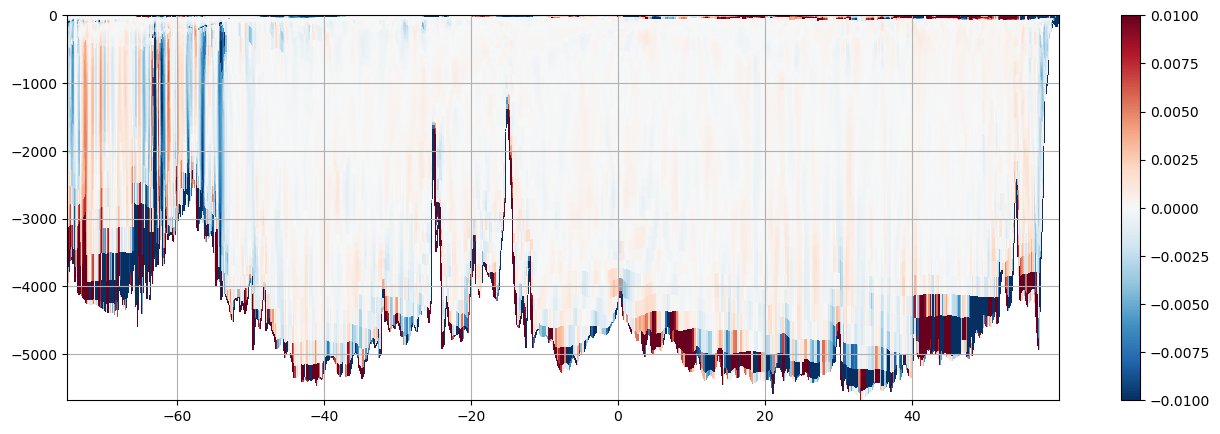

In [55]:
plt.figure(figsize=(16, 5))
plot_om4_section_yqi()

/state/partition1/job-62242391/ipykernel_3904893/724297832.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2, cmap='RdBu_r')


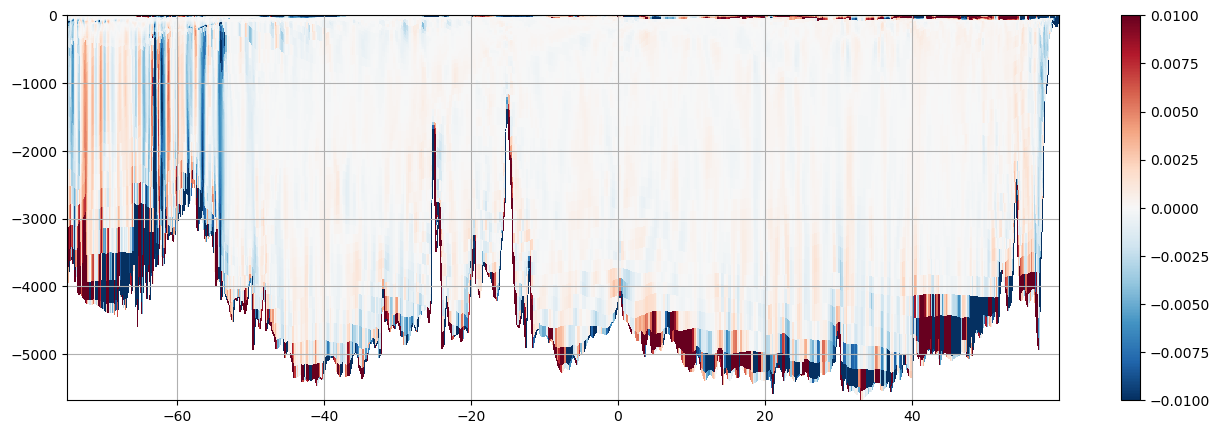

In [56]:
plt.figure(figsize=(16, 5))
plot_om4_section_yqi(var = 'ANN_slope_y')

In [57]:
def plot_om4_section_T(ds=ds, var='dhdy',
                       tsel = 0,
                        yh_sel = slice(-75,60),
                        yq_sel = slice(-75,59.9),
                        xsel = -149, vmin =-0.01, vmax=0.01):
    
    e = ds.e.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
    e_mid = 0.5*(e[1:,:] + e[0:-1,:])
    x = ds.yh.sel(yh=yh_sel).data

    c = ds[var].isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data

    plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.grid()

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


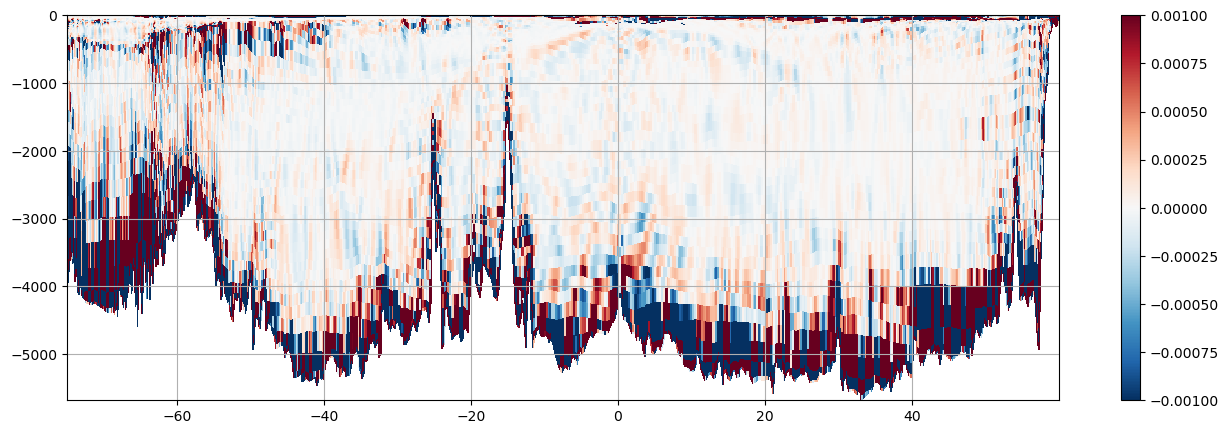

In [59]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(vmin =-0.001, vmax=0.001)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


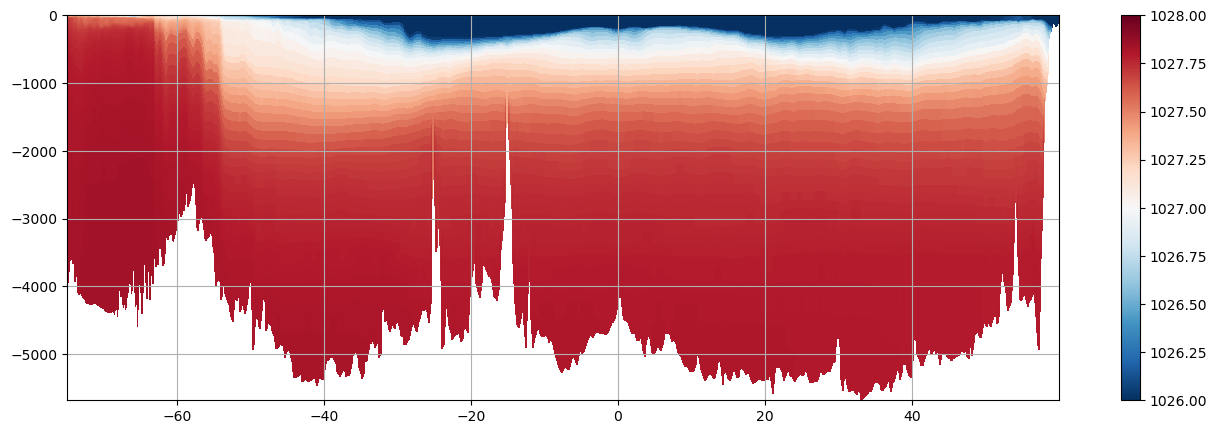

In [67]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='rhopot0', vmin =1026, vmax=1028)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


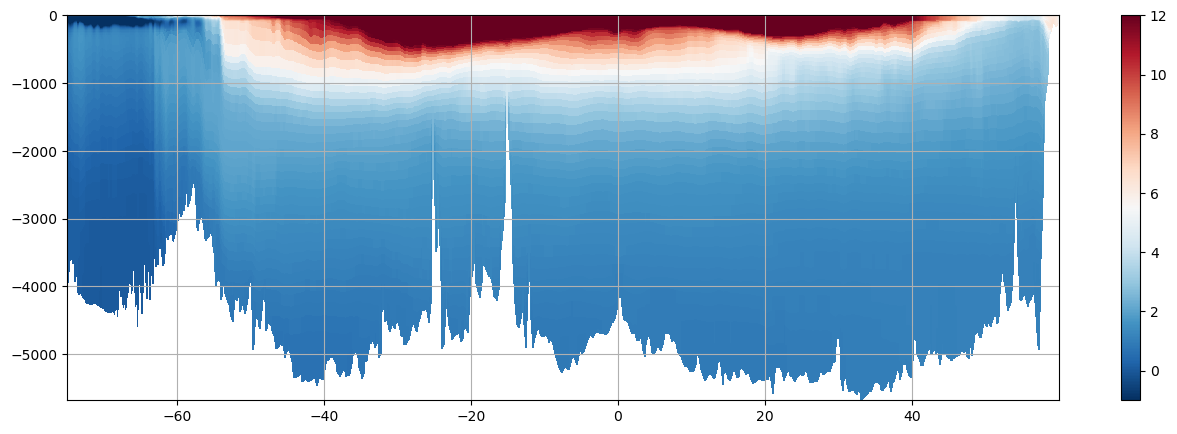

In [74]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='thetao', vmin =-1, vmax=12)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


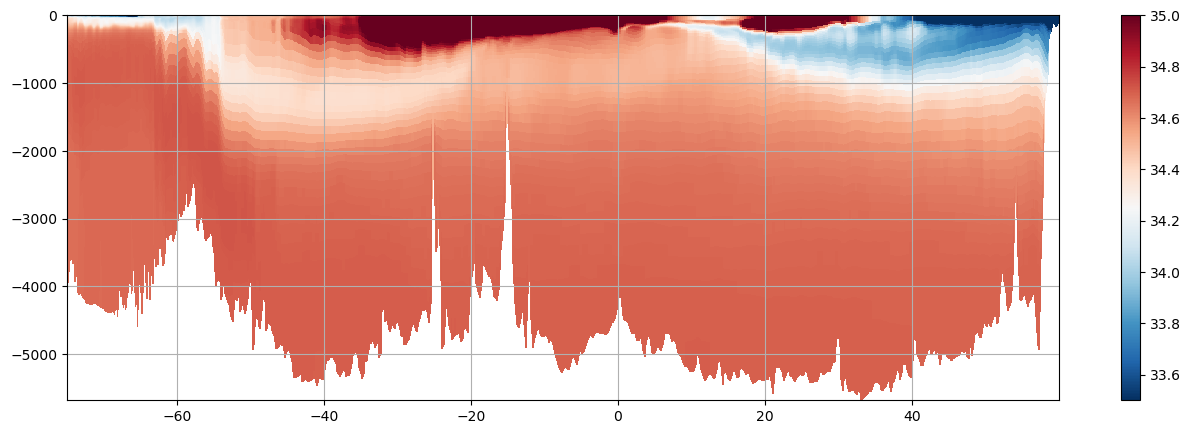

In [78]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='so', vmin =33.5, vmax=35)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


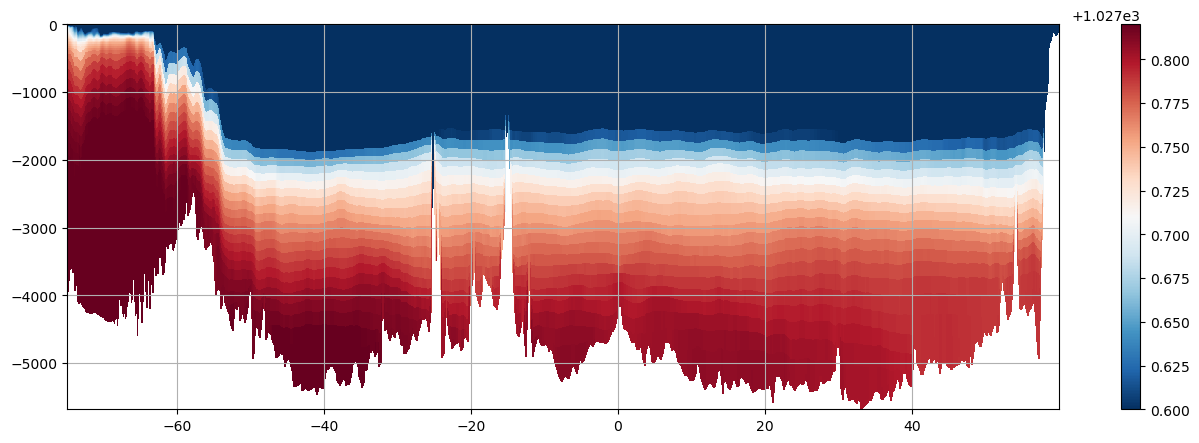

In [72]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='rhopot0', vmin =1027.6, vmax=1027.82)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


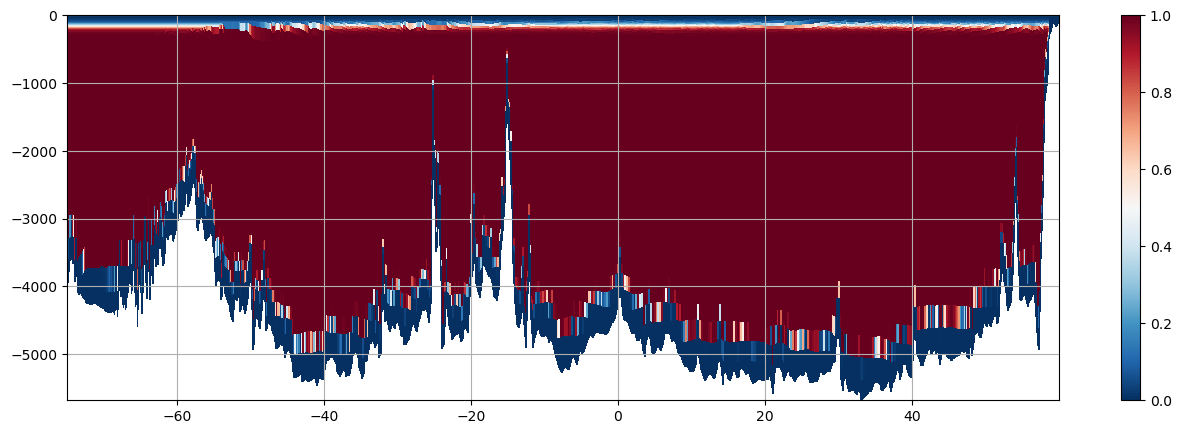

In [79]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='boundary_mask', vmin =0, vmax=1)

/state/partition1/job-62242391/ipykernel_3904893/533208740.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


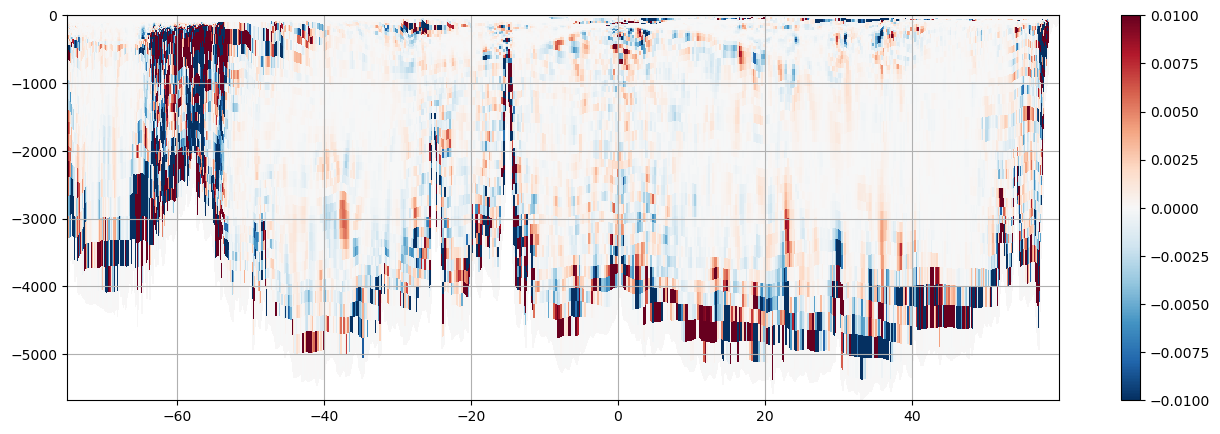

In [82]:
plt.figure(figsize=(16, 5))
plot_om4_section_T(var='Fy', vmin =-0.01, vmax=0.01)

In [23]:
def plot_om4_section_yhi(ds=ds, var='N2', 
                     tsel=0, 
                     yh_sel = slice(-75,60),
                     #yq_sel = slice(-75,59.9), 
                     xsel = -149,
                     vmin = -7.5, vmax=-3,
                    log_scale=True) :
    
    e = ds.e.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
    x = ds.yh.sel(yh=yh_sel).data
    c = ds[var].isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
    if log_scale:
        c = np.log10(c)
    plt.pcolormesh(np.tile(x[:,None],76).T,e, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.grid()

/ext3/miniforge/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in log10
  return func(*(_execute_task(a, cache) for a in args))
/state/partition1/job-62270271/ipykernel_3695061/1145121040.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


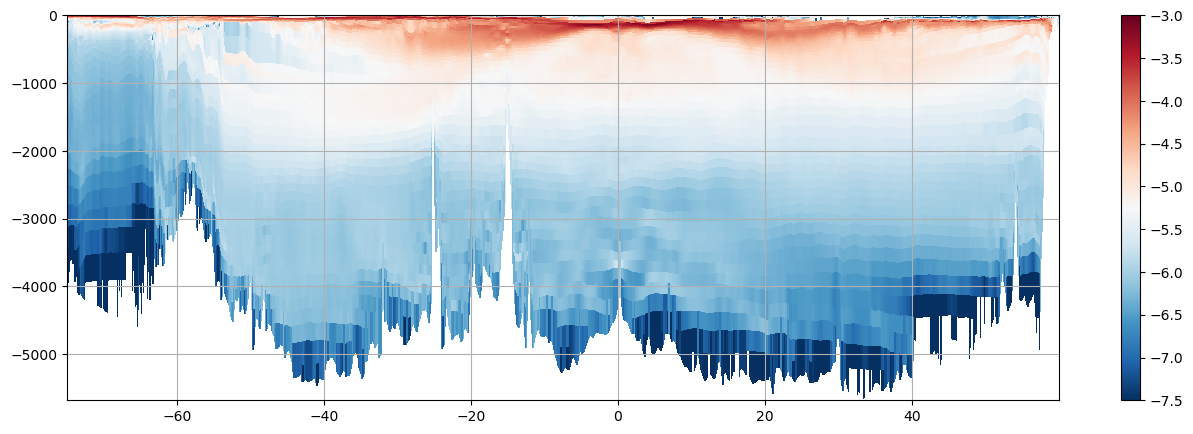

In [24]:
plt.figure(figsize=(16, 5))
plot_om4_section_yhi()

/state/partition1/job-62270271/ipykernel_3695061/1145121040.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e, c, vmin=vmin, vmax=vmax, cmap='RdBu_r')


(-500.0, 0.0)

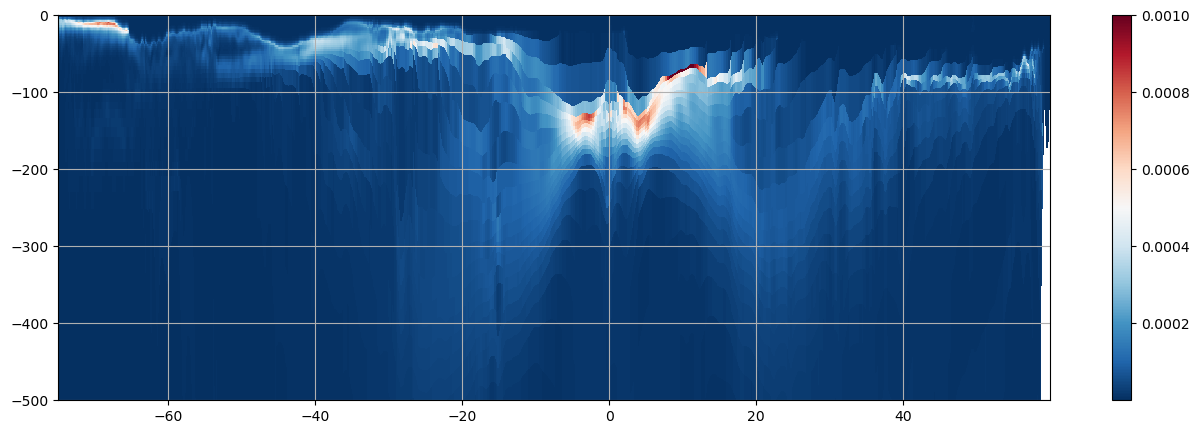

In [29]:
plt.figure(figsize=(16, 5))
plot_om4_section_yhi(log_scale=False, vmin=1e-8, vmax=1e-3)
plt.ylim(-500,0)

# Scraps

/state/partition1/job-62242391/ipykernel_3904893/869974779.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=-0.01, vmax=0.01, cmap='RdBu_r')


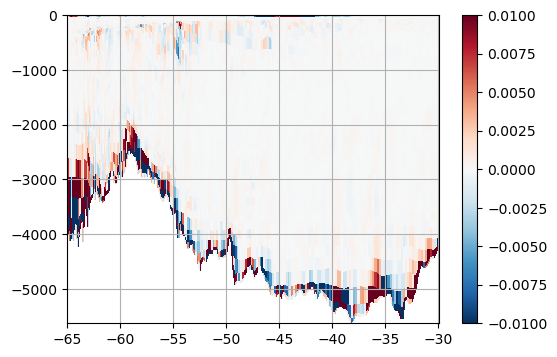

In [31]:
plt.figure(figsize=(6, 4))
plot_om4_section_T()

/state/partition1/job-62242391/ipykernel_3904893/3428620119.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2, cmap='RdBu_r')


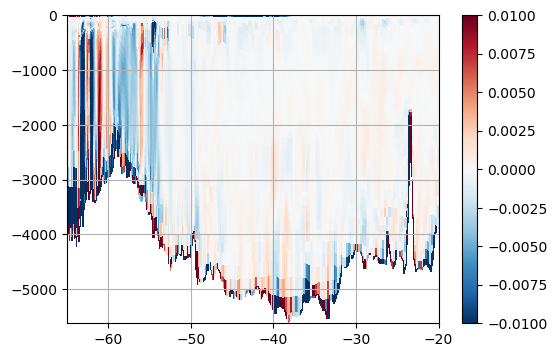

In [25]:
plt.figure(figsize=(6, 4))
plot_om4_section_yqi(yh_sel = slice(-65,-20),
                     yq_sel = slice(-65,-19.9),)

/state/partition1/job-62242391/ipykernel_3904893/869974779.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2, cmap='RdBu_r')


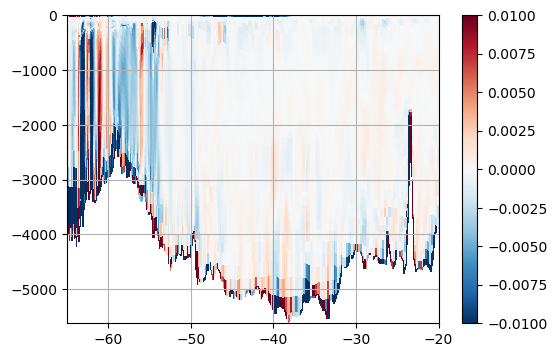

In [32]:
plt.figure(figsize=(6, 4))
plot_om4_section_yqi(yh_sel = slice(-65,-20),
                     yq_sel = slice(-65,-19.9),)

/state/partition1/job-62242391/ipykernel_3904893/869974779.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=-0.01, vmax=0.01, cmap='RdBu_r')


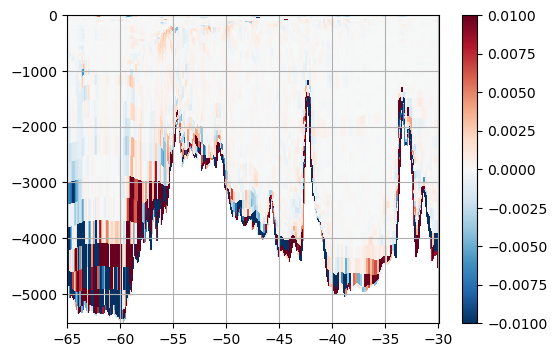

In [34]:
plt.figure(figsize=(6, 4))
plot_om4_section_T(var='dhdy', xsel=0)

/state/partition1/job-62242391/ipykernel_3904893/869974779.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=-0.01, vmax=0.01, cmap='RdBu_r')


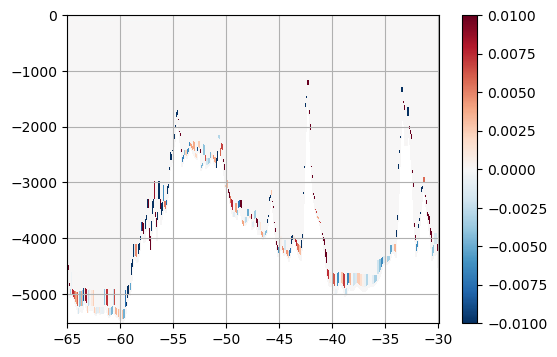

In [33]:
plt.figure(figsize=(6, 4))
plot_om4_section_T(var='dhbardy', xsel=0)

In [8]:
tsel = 0
yh_sel = slice(-65,-30)
yq_sel = slice(-65,-29.9)
xsel = -150

e = ds.e.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
x = ds.yh.sel(yh=yh_sel).data
c = ds.neutral_slope_y.isel(time=tsel).sel(yq=yq_sel).sel(xh=xsel, method='nearest').data

/state/partition1/job-62236290/ipykernel_2956933/2460521539.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2)


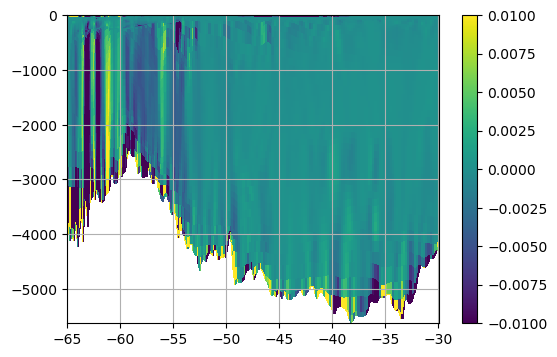

In [9]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(np.tile(x[:,None],76).T,e,c, vmin=-1e-2, vmax=1e-2)
plt.colorbar()
plt.grid()

In [28]:
tsel = 0
yh_sel = slice(-65,-30)
yq_sel = slice(-65,-29.9)
xsel = -150

e = ds.e.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
e_mid = 0.5*(e[1:,:] + e[0:-1,:])
x = ds.yh.sel(yh=yh_sel).data
c = ds.Fy.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
c_dhdy = ds.dhdy.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data
c_mask = ds.boundary_mask.isel(time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').data

/state/partition1/job-62242391/ipykernel_3904893/2453041007.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=-0.1, vmax=0.1, cmap='RdBu_r')


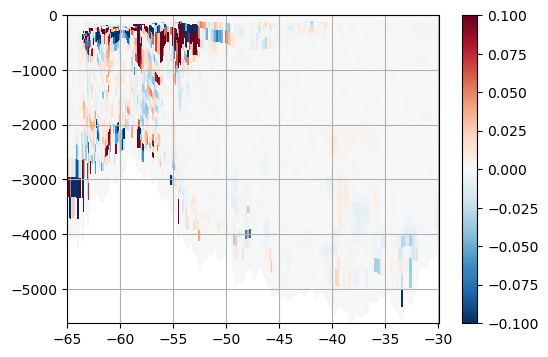

In [29]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(np.tile(x[:,None],75).T,e_mid, c, vmin=-0.1, vmax=0.1, cmap='RdBu_r')
plt.colorbar()
plt.grid()

/state/partition1/job-62236290/ipykernel_2956933/3433648170.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid,c_dhdy, vmin=-0.01, vmax=0.01, cmap='RdBu_r')


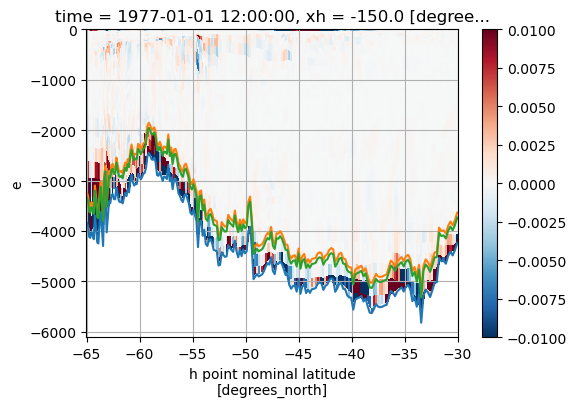

In [20]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(np.tile(x[:,None],75).T,e_mid,c_dhdy, vmin=-0.01, vmax=0.01, cmap='RdBu_r')
ds.e.isel(zi=-1, time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').plot()
(ds.e + 600).isel(zi=-1, time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').plot()
(ds.e + 500).isel(zi=-1, time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').plot()
plt.colorbar()
plt.grid()

/state/partition1/job-62236290/ipykernel_2956933/1048950360.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,e_mid,c_mask)


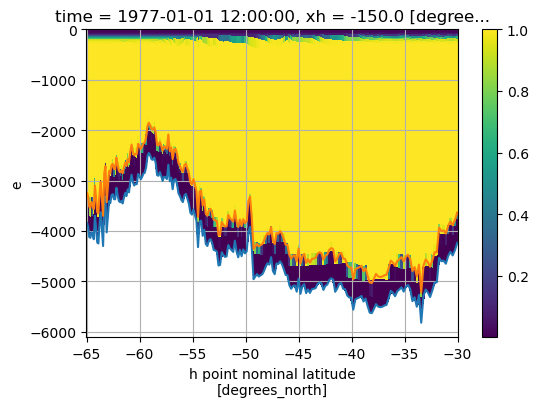

In [18]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(np.tile(x[:,None],75).T,e_mid,c_mask)
ds.e.isel(zi=-1, time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').plot()
(ds.e + 600).isel(zi=-1, time=tsel).sel(yh=yh_sel).sel(xh=xsel, method='nearest').plot()
plt.colorbar()
plt.grid()

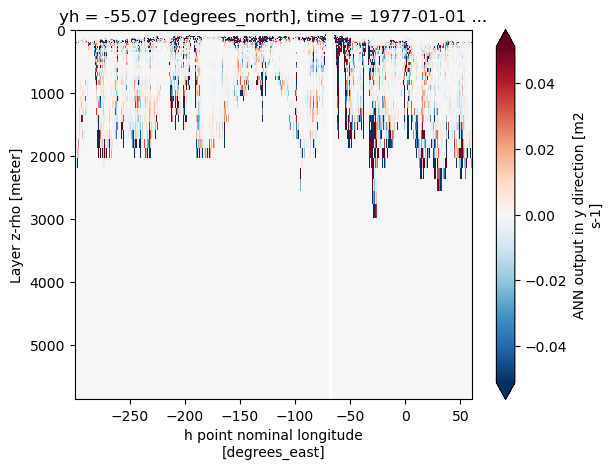

In [16]:
ds.Fy.isel(time=-1).sel(yh=-55, method='nearest').plot(robust=True)
plt.gca().invert_yaxis()

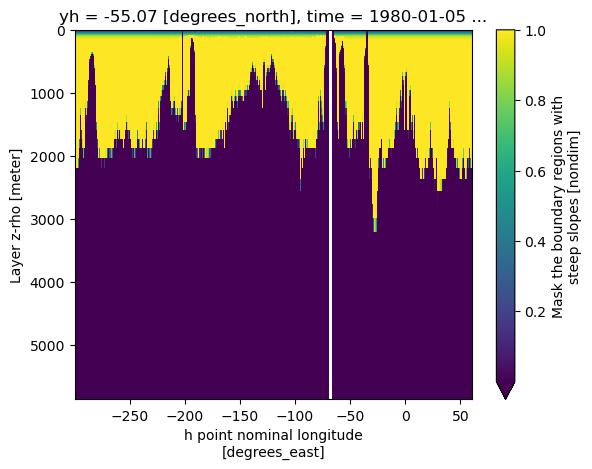

In [7]:
ds.boundary_mask.isel(time=-1).sel(yh=-55, method='nearest').plot(robust=True)
plt.gca().invert_yaxis()

In [11]:
ds.boundary_mask.isel(time=-1).sel(yh=-55, method='nearest').plot(y='e', robust=True)
plt.gca().invert_yaxis()

ValueError: y must be one of None, 'time', 'xh', 'yh', 'zl'. Received 'e' instead.

In [12]:
ds.e

<xarray.DataArray 'e' (time: 4, zi: 76, yh: 1080, xh: 1440)>
dask.array<concatenate, shape=(4, 76, 1080, 1440), dtype=float64, chunksize=(1, 76, 1080, 1440), chunktype=numpy.ndarray>
Coordinates:
  * yh       (yh) float64 -80.39 -80.31 -80.23 -80.15 ... 89.73 89.84 89.95
  * time     (time) object 1980-01-02 00:00:00 ... 1980-01-05 00:00:00
  * xh       (xh) float64 -299.7 -299.5 -299.2 -299.0 ... 59.53 59.78 60.03
  * zi       (zi) float64 0.0 2.0 4.0 6.0 ... 3.461e+03 3.722e+03 6.5e+03
Attributes:
    long_name:     Interface Height Relative to Mean Sea Level
    units:         m
    cell_methods:  area:mean zi:point yh:mean xh:mean time: point

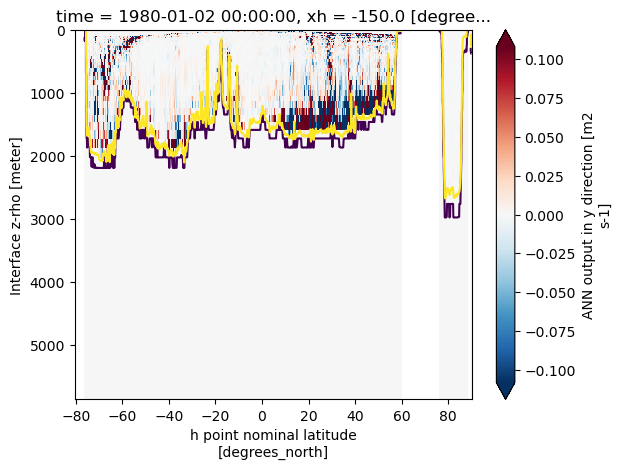

In [6]:
ds.Fy.isel(time=0).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

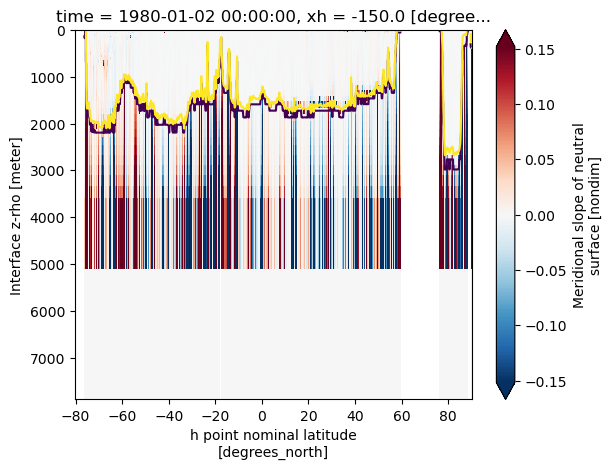

In [7]:
ds.ANN_slope_y.isel(time=0).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

/state/partition1/job-62131990/ipykernel_2148439/2181472780.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,y,z, vmin=-1e-3, vmax=1e-3)


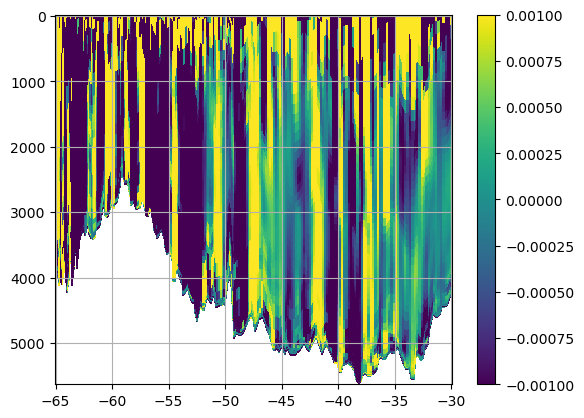

In [9]:
x = ds.yh.sel(yh=slice(-65, -30)).data
y = (ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').sel(yh=slice(-65, -30)).data
z = ds.neutral_slope_y.isel(time=0).sel(xh=-150, method='nearest').sel(yq=slice(-65, -29.9)).data

plt.pcolormesh(np.tile(x[:,None],76).T,y,z, vmin=-1e-3, vmax=1e-3)
plt.colorbar()
plt.gca().invert_yaxis()
plt.grid()

/state/partition1/job-62131990/ipykernel_2148439/459335290.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],76).T,y,z, vmin=-1e-2, vmax=1e-2)


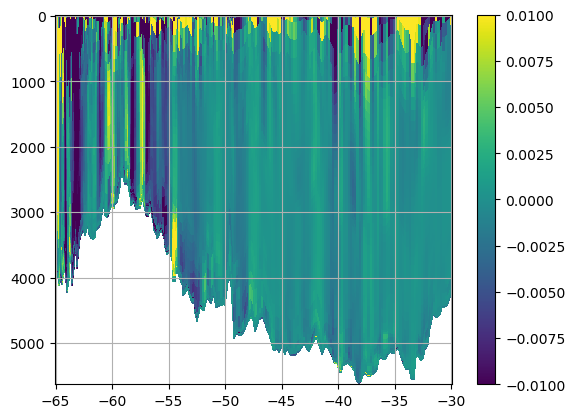

In [10]:
plt.pcolormesh(np.tile(x[:,None],76).T,y,z, vmin=-1e-2, vmax=1e-2)
plt.colorbar()
plt.gca().invert_yaxis()
plt.grid()

/state/partition1/job-62131990/ipykernel_2148439/3687626687.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,y,z, vmin=-0.1, vmax=0.1)


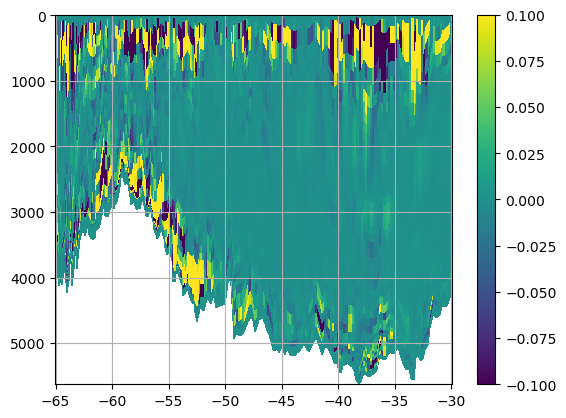

In [18]:
x = ds.yh.sel(yh=slice(-65, -30)).data
y = (ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').sel(yh=slice(-65, -30)).data
y = 0.5*(y[0:-1] + y[1:])
z = ds.Fy.isel(time=0).sel(xh=-150, method='nearest').sel(yh=slice(-65, -30)).data


plt.pcolormesh(np.tile(x[:,None],75).T,y,z, vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.gca().invert_yaxis()
plt.grid()

/state/partition1/job-62131990/ipykernel_2148439/519692657.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(np.tile(x[:,None],75).T,y,z, vmin=-0.5, vmax=0.5, cmap='RdBu_r')


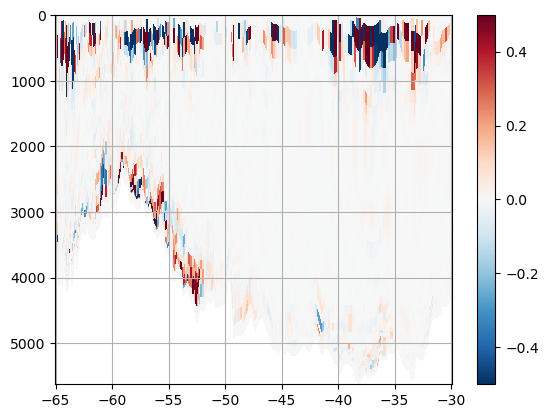

In [19]:
x = ds.yh.sel(yh=slice(-65, -30)).data
y = (ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').sel(yh=slice(-65, -30)).data
y = 0.5*(y[0:-1] + y[1:])
z = ds.Fy.isel(time=0).sel(xh=-150, method='nearest').sel(yh=slice(-65, -30)).data


plt.pcolormesh(np.tile(x[:,None],75).T,y,z, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar()
plt.gca().invert_yaxis()
plt.grid()

In [15]:
x.shape, y.shape, z.shape

((220,), (75, 220), (75, 220))

In [39]:
x[:, None].shape

(1080, 1)

In [36]:
y.shape

(76, 1080)

In [38]:
z.shape

(76, 1080)

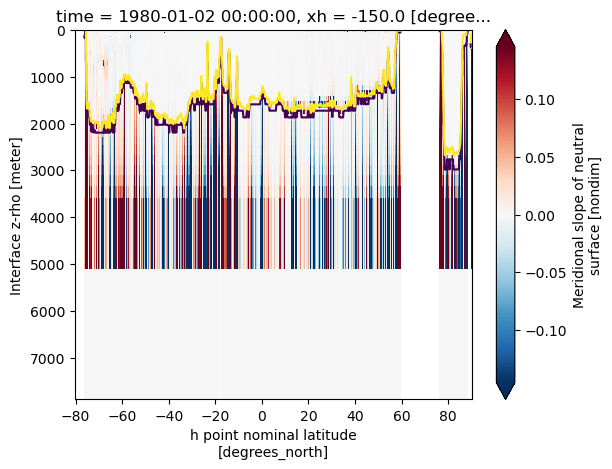

In [29]:
ds.neutral_slope_y.isel(time=0).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

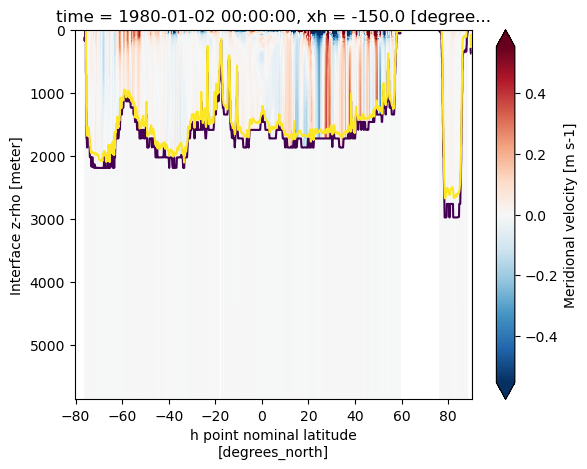

In [30]:
ds.v.isel(time=0).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

In [28]:
ds..isel(time=0).sel(xh=-150, method='nearest').plot(vmin=-5e-3)
(ds.e - ds.e.isel(zi=-1)).isel(time=0).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

AttributeError: 'Dataset' object has no attribute 'dudy'

In [ ]:
ds.Fy.isel(time=-1).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=-1).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

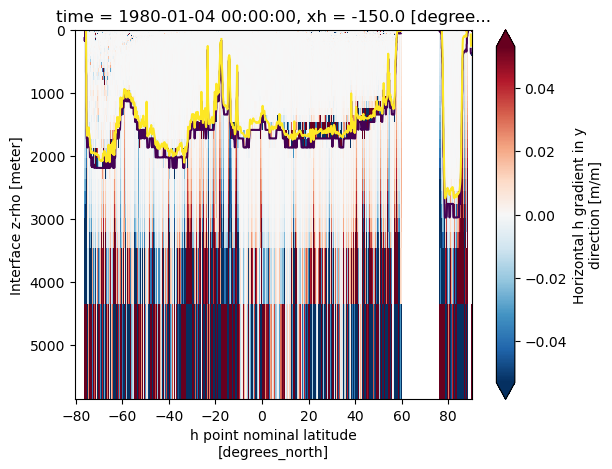

In [22]:
ds.dhdy.isel(time=-1).sel(xh=-150, method='nearest').plot(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=-1).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

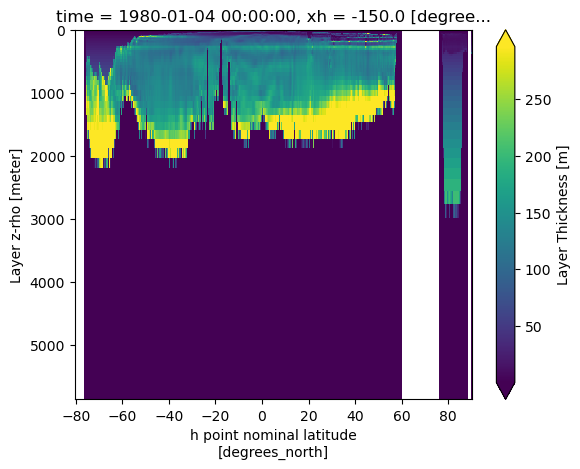

In [9]:
ds.h.isel(time=-1).sel(xh=-150, method='nearest').plot(robust=True)
plt.gca().invert_yaxis()

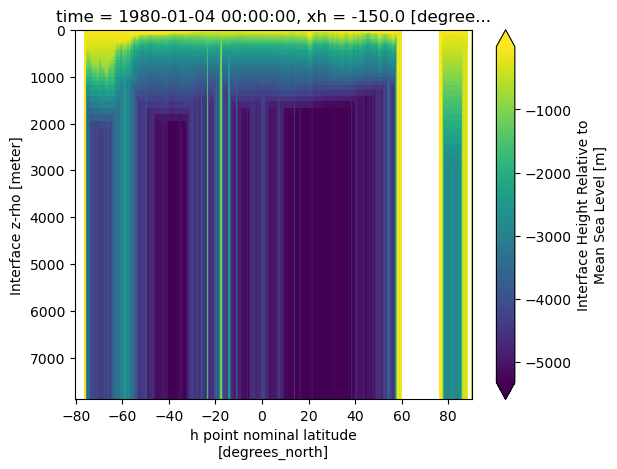

In [10]:
ds.e.isel(time=-1).sel(xh=-150, method='nearest').plot(robust=True)
plt.gca().invert_yaxis()

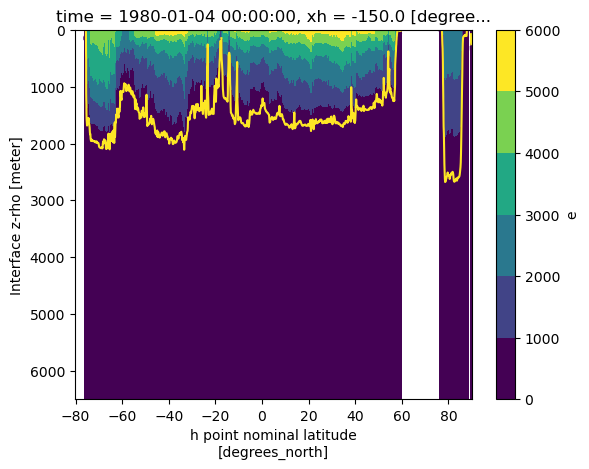

In [19]:
(ds.e - ds.e.isel(zi=-1)).isel(time=-1).sel(xh=-150, method='nearest').plot.contourf(robust=True)
(ds.e - ds.e.isel(zi=-1)).isel(time=-1).sel(xh=-150, method='nearest').plot.contour(levels=[1,200])

plt.gca().invert_yaxis()

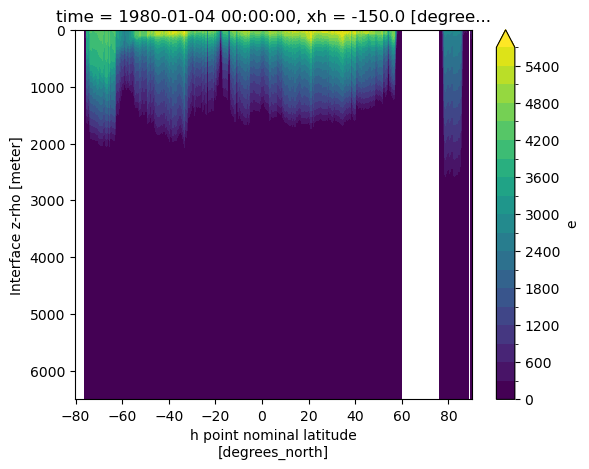

In [14]:
(ds.e - ds.e.isel(zi=-1)).isel(time=-1).sel(xh=-150, method='nearest').plot.contourf(levels=21,robust=True)
plt.gca().invert_yaxis()